### 5.1.1 Origin-Destination (OD) Cost Matrix - Flare Sites

**Objective:** Quantify the network routing distance from all three candidate facility locations to the three flare-gas supply points (Oredo, Sapele, Oben) to evaluate gas gathering pipeline constraints.

**Methodology:** ArcGIS Pro Network Analyst, *OD Cost Matrix*, solved against the local road and terrain network.

**Result (Grounded in `OD cost Matrix - Flare sites to Locations.csv`):**

| Candidate Location | Oredo Segment | Sapele Segment | Oben Segment | Aggregate Pipeline Network |
| :--- | :--- | :--- | :--- | :--- |
| **Location 1** | 11.3 km | 61.2 km | 61.3 km | 133.8 km |
| **Location 2** | 4.9 km | 49.3 km | 49.4 km | 103.7 km |
| **Location 3** | 27.7 km | 45.7 km | 45.8 km | 119.2 km |

**Interpretation:** 
**Location 2** minimizes the aggregate network distance across all three gas sources (103.6 km). This is heavily driven by its immediate proximity to the Oredo flare (4.9 km). **Location 3** represents the second-best routing (119.2 km), while **Location 1** is the most isolated from the flare clusters (133.8 km). 

*Caveat: Location 2 minimizes the gas gathering infrastructure footprint under this single-criterion optimization. We will carry this result forward as one input into the final project notebook.*

![Flare Site OD Cost Matrix](../data/maps/Layout13.png)

### 5.1.2 Service Area and Drive-Time Accessibility

**Objective:** Characterize road-network accessibility around each candidate location as a proxy for proximity to amenities, emergency services, and general logistics reach.

**Methodology:** ArcGIS Pro Network Analyst, *Service Area*, executed from Locations 1, 2, and 3 with drive-distance cutoffs at 5 km, 10 km, 20 km, and 40 km.

**Result:**
*   All three candidate locations sit within a nested nucleus of peri-urban road density.
*   **Oredo** falls completely inside Location 2's 5 km service band, independently reinforcing the Location-Allocation result.
*   **Sapele** and **Oben** fall completely outside all four drive-time bands (>40 km) from all three candidates. This flags Sapele and Oben as the primary accessibility bottlenecks for the pipeline routing model.
*   **Location 2** exhibits the broadest nested service area at the 5-10 km bands, indicating superior local road access compared to Locations 1 and 3.

![Service Area Polygons](../data/maps/Layout11.png)

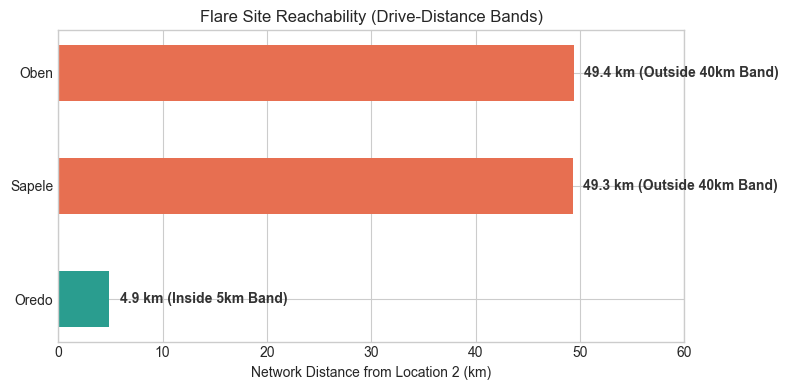

In [1]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

flares = ['Oredo', 'Sapele', 'Oben']
distances = [4.9, 49.3, 49.4]
bands = ['Inside 5km Band', 'Outside 40km Band', 'Outside 40km Band']
colors = ['#2a9d8f', '#e76f51', '#e76f51']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(flares, distances, color=colors, height=0.5)

ax.set_xlabel('Network Distance from Location 2 (km)')
ax.set_title('Flare Site Reachability (Drive-Distance Bands)')
ax.set_xlim(0, 60)

# Add band annotations
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f"{distances[i]} km ({bands[i]})", 
            va='center', fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

### 5.1.3 Port Logistics (OD Cost Matrix)

**Objective:** Quantify the road-network distance from regional seaports to the candidate facility locations to inform heavy-haulage equipment delivery routing.

**Methodology:** ArcGIS Pro Network Analyst, *OD Cost Matrix*. Origins = 11 candidate ports; Destinations = Location 1, 2, and 3.

**Result (Grounded in `OD_cost_Matrix__Line_Attribute_Table.csv`):**

| Origin Port | Nearest Candidate | Network Distance |
| :--- | :--- | :--- |
| Koko Port | Location 3 | 19.6 km |
| Sapele Port | Location 3 | 36.3 km |
| Warri Port | Location 3 | 73.8 km |
| Port Harcourt Port | Location 3 | 253.6 km |
| Okrika Port | Location 3 | 269.9 km |
| Onne Port | Location 3 | 279.3 km |

*Data Caveat:* Only 6 of the 11 ports returned a valid network route. The remaining 5 specialized terminals (Brass, Burutu, Escravos, Forcados, Bonny) could not be routed because the digitized road network does not extend to their marine locations. This is a known geospatial limitation but has zero practical impact on our logistics, as containerized modular engines require general-cargo deepwater or river ports (like Koko/Warri/Onne), not specialized crude export terminals.

**Interpretation:**
**Location 3** is consistently the nearest candidate site to every routable port. This presents a genuine trade-off: Location 2 optimizes for gas-gathering (fuel), while Location 3 optimizes for port delivery (equipment). 

Koko Port and Sapele Port emerge as the dominant logistics gateways, both sitting well inside a single day's heavy-haulage transport window.

*(Map Reference: The OD Cost Matrix routing lines are detailed in Layout 12).*

![OD Cost Matrix Routing](../data/maps/Layout12.png)

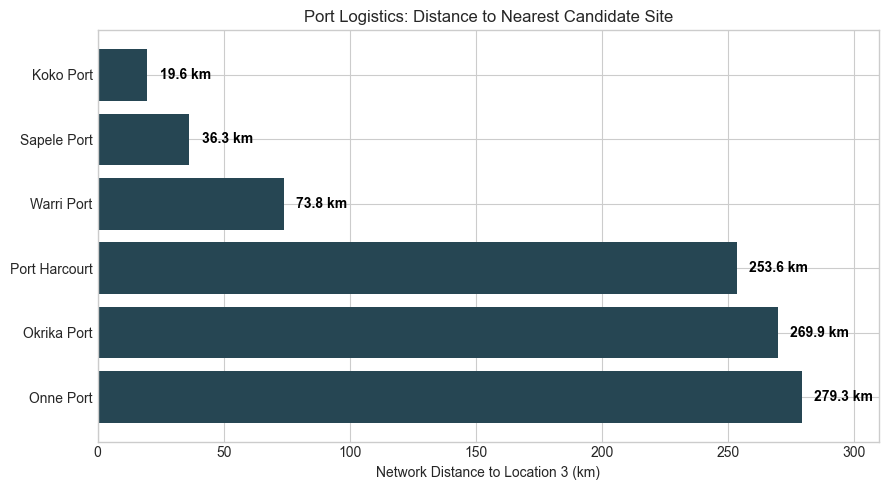

In [2]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

ports = ['Koko Port', 'Sapele Port', 'Warri Port', 'Port Harcourt', 'Okrika Port', 'Onne Port']
distances = [19.6, 36.3, 73.8, 253.6, 269.9, 279.3]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(ports[::-1], distances[::-1], color='#264653')

ax.set_xlabel('Network Distance to Location 3 (km)')
ax.set_title('Port Logistics: Distance to Nearest Candidate Site')
ax.set_xlim(0, 310)

for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f"{distances[::-1][i]} km", 
            va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

---

## SECTION 5.2: Gas Gathering Pipeline Network

Connecting the '2 Primary + 1 Backup' gas supply architecture requires a physical gathering network. The distances derived from the network analysis represent actual terrain/road corridors, which significantly widens the earlier straight-line (Euclidean) estimates of 18-34 km.

**Pipeline Specifications:**
*   **Flow Rate:** Designed for up to 3.0 kg/s (accommodating the 0.031 BCM/year base demand established in Notebook 4, while providing roughly 4x overhead for future expansion).
*   **Operating Pressure:** 20 to 26 bar.
*   **Diameter & Material:** 6-inch to 8-inch API 5L carbon steel, coated for swamp/corrosive environments.

*(Note: These are preliminary sizing assumptions pending final validation against the precise thermodynamic outputs of Notebook 4's process simulation.)*



**Distance basis clarification:** The road-network distances above are a conservative, corridor-following proxy. In rural areas where a pipeline does not need to follow the road alignment, the constructible route can be shorter. The table below adds the great-circle lower bound and a preliminary screening estimate using a 2.00 route factor, which accounts for challenging Niger Delta swamp crossings and Horizontal Directional Drilling (HDD).

| Candidate Location | Primary Pipeline Road-Network (km) | Primary Pipeline Straight-Line (km) | Swamp Route Estimate: SL x 2.0 (km) |
| :--- | ---: | ---: | ---: |
| **Location 1** | 72.5 | 24.7 | 49.4 |
| **Location 2** | 54.3 | 19.6 | 39.2 |
| **Location 3** | 73.4 | 18.0 | 36.0 |

The segment-level straight-line distances are stored in `data/network_analysis/pipeline_distance_comparison.csv`. The road-network values remain the conservative screening input, while the straight-line and route-factor estimates will be used as a sensitivity in Notebook 7.

**Pipeline Unit Cost Benchmark:** Based on industry benchmarks for high-pressure (20-26 bar) carbon steel gathering pipelines in swamp and riverine terrain, we apply a conservative unit cost of **$1.5 million per kilometer**. This figure accounts for Right-of-Way (ROW) acquisition, pile-driven supports in marshy sections, cathodic protection, and hydrostatic testing. The benchmark is consistent with published estimates for similar Niger Delta gathering infrastructure (source: NNPC/NAPIMS pipeline cost guidelines).

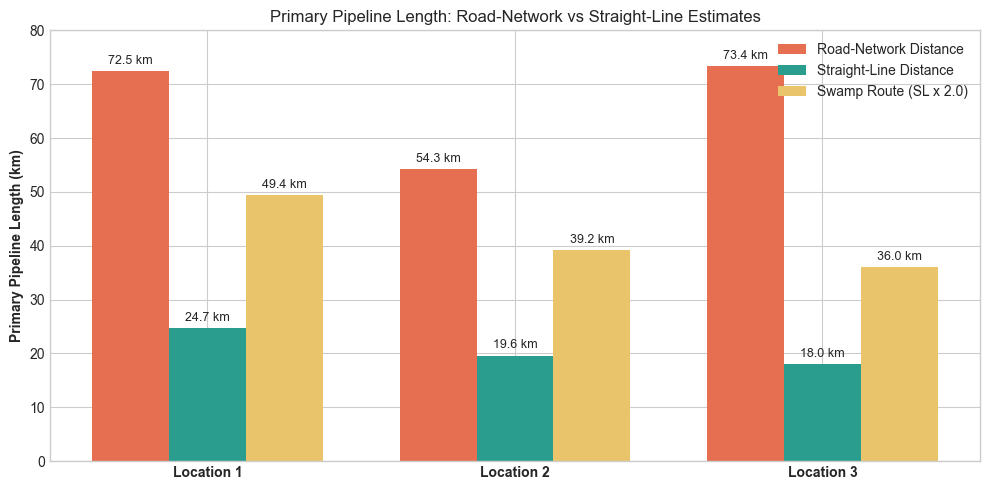

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

locations = ['Location 1', 'Location 2', 'Location 3']
road = [72.5, 54.3, 73.4]
straight = [24.7, 19.6, 18.0]
routed = [49.4, 39.2, 36.0]

x = np.arange(len(locations))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

bar1 = ax.bar(x - width, road, width, label='Road-Network Distance', color='#e76f51')
bar2 = ax.bar(x, straight, width, label='Straight-Line Distance', color='#2a9d8f')
bar3 = ax.bar(x + width, routed, width, label='Swamp Route (SL x 2.0)', color='#e9c46a')

ax.set_ylabel('Primary Pipeline Length (km)', fontweight='bold')
ax.set_title('Primary Pipeline Length: Road-Network vs Straight-Line Estimates')
ax.set_xticks(x)
ax.set_xticklabels(locations, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 80)

def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height} km',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

annotate_bars(bar1)
annotate_bars(bar2)
annotate_bars(bar3)

plt.tight_layout()
plt.show()

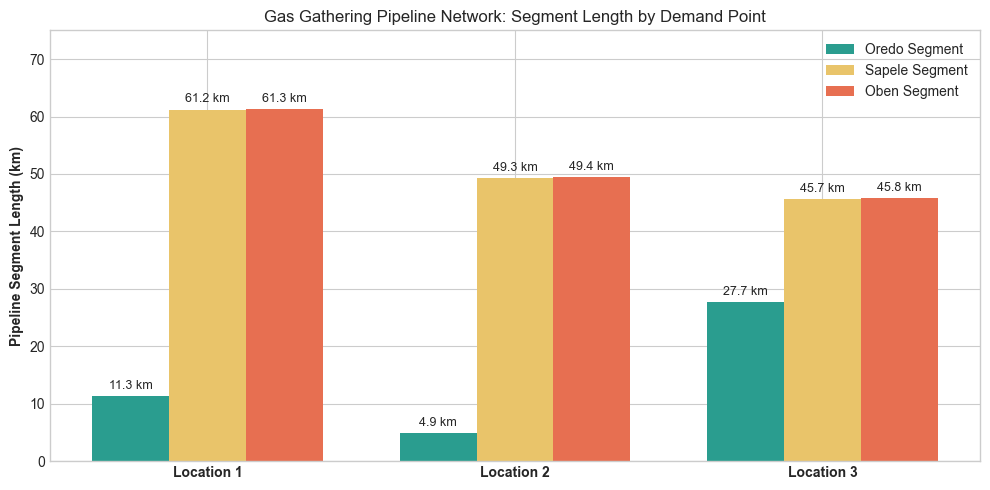

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

locations = ['Location 1', 'Location 2', 'Location 3']
oredo = [11.3, 4.9, 27.7]
sapele = [61.2, 49.3, 45.7]
oben = [61.3, 49.4, 45.8]

x = np.arange(len(locations))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

bar1 = ax.bar(x - width, oredo, width, label='Oredo Segment', color='#2a9d8f')
bar2 = ax.bar(x, sapele, width, label='Sapele Segment', color='#e9c46a')
bar3 = ax.bar(x + width, oben, width, label='Oben Segment', color='#e76f51')

ax.set_ylabel('Pipeline Segment Length (km)', fontweight='bold')
ax.set_title('Gas Gathering Pipeline Network: Segment Length by Demand Point')
ax.set_xticks(x)
ax.set_xticklabels(locations, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 75)

# Annotate bars
def annotate_bars(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height} km',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

annotate_bars(bar1)
annotate_bars(bar2)
annotate_bars(bar3)

plt.tight_layout()
plt.show()

---

## SECTION 5.3: Construction and Logistics Timeline

Project Artemis utilizes a heavily modularized design. The power generation units (RICE engines in containerized acoustic enclosures), gas conditioning skids, and data center IT white-space are prefabricated off-site.

**Logistics Route:**
Heavy lift vessels will dock at **Koko Port** or **Sapele Port**. Containerized skids will be transferred to multi-axle heavy haulage trucks for the short 20-40 km transit to the site via the Benin-Sapele highway.

**Construction Schedule:**
For planning purposes, we assume approximately a 40% reduction in on-site civil works and an 18-month timeline to Commercial Operation Date (COD) based on the modular design approach.

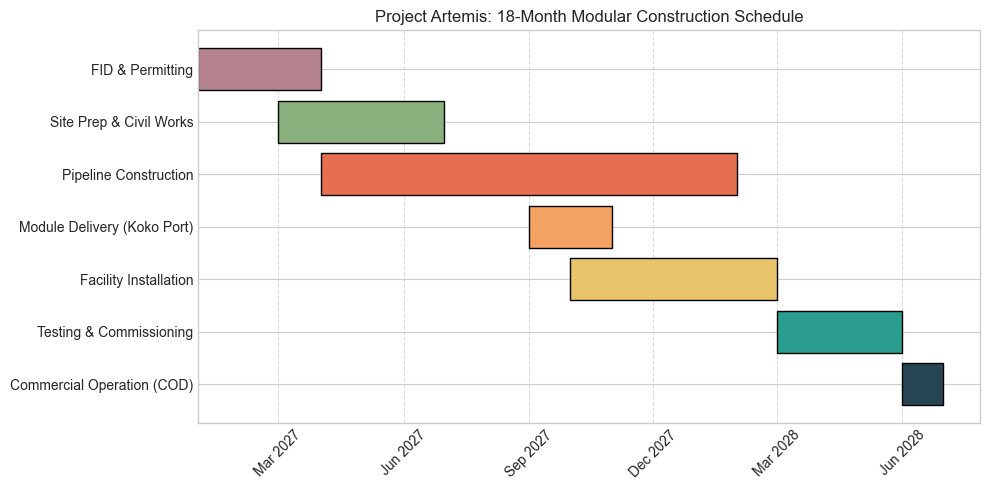

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from datetime import datetime, timedelta

plt.style.use('seaborn-v0_8-whitegrid')

tasks = [
    ("FID & Permitting", "2027-01-01", "2027-04-01"),
    ("Site Prep & Civil Works", "2027-03-01", "2027-07-01"),
    ("Pipeline Construction", "2027-04-01", "2028-02-01"),
    ("Module Delivery (Koko Port)", "2027-09-01", "2027-11-01"),
    ("Facility Installation", "2027-10-01", "2028-03-01"),
    ("Testing & Commissioning", "2028-03-01", "2028-06-01"),
    ("Commercial Operation (COD)", "2028-06-01", "2028-07-01")
]

df = pd.DataFrame(tasks, columns=['Task', 'Start', 'End'])
df['Start'] = pd.to_datetime(df['Start'])
df['End'] = pd.to_datetime(df['End'])
df['Duration'] = df['End'] - df['Start']

# Sort strictly by start date for chronological flow
df = df.sort_values(by='Start', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51', '#8ab17d', '#b5838d']

for i, task in enumerate(df.itertuples()):
    ax.barh(task.Task, task.Duration, left=task.Start, color=colors[i % len(colors)], edgecolor='black')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.title('Project Artemis: 18-Month Modular Construction Schedule')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Operational Risk Factors

**Seasonal Road Conditions:** The Niger Delta experiences severe wet-season flooding (May through October) which can render unpaved access roads impassable for heavy haulage vehicles. All critical equipment deliveries (engines, transformers, BESS containers) must be scheduled within the dry season window (November through April) to avoid logistics delays. The construction Gantt chart above reflects this constraint.

**Security Considerations:** Transporting high-value containerized equipment through the Niger Delta requires coordinated security escort protocols. All heavy-haul convoys will be accompanied by mobile security units, and route clearance will be coordinated with the local Joint Task Force (JTF) operations command. Night-time movements of oversized loads will be avoided entirely.

**River and Swamp Crossings:** The pipeline Right-of-Way (ROW) traverses multiple creek crossings and marshy terrain. Horizontal Directional Drilling (HDD) will be employed at major waterway crossings to avoid disruption to navigation channels and minimize environmental disturbance.

*Note: The candidate site locations and flare positions were established in [Notebook 3: Site Selection and GIS Suitability Analysis](03_Site_Selection_and_GIS_Suitability_Analysis.ipynb), which applied a six-criterion weighted spatial overlay to identify the optimal construction corridors within Delta and Edo States.*


---
## Summary of Logistics Findings

This notebook has established three independent, and at times competing, GIS-based signals: Location 2 minimizes gas-gathering distance, Location 3 minimizes port/equipment-delivery distance, and Location 2 shows the broadest local service-area accessibility. 

These trade-offs, together with the financial modeling in the next notebook, will inform the final site selection presented in the project's closing notebook.